<a href="https://colab.research.google.com/github/hafizapatel04-bit/f1_Prediction/blob/main/visualizationOfF1brazilgp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fastf1



In [ ]:
import numpy as np
import matplotlib as mp
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.collections import LineCollection
import fastf1 as f1


In [ ]:
year = 2023
wknd = 21
ses = "R"
driver = 'HAM'
colormap =mp.cm.plasma

In [ ]:
session = f1.get_session(year, wknd, ses)
session.load()
weekend = session.event

core           INFO 	Loading data for Las Vegas Grand Prix - Race [v3.6.1]
INFO:fastf1.fastf1.core:Loading data for Las Vegas Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
DEBUG:fastf1.ergast:Failed to parse timestamp '-1:54:30.642' in Ergastresponse.
DEBUG:fastf1.ergast:Failed to parse timestamp '-1:52:35.501' in Ergastresponse.
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached 

In [ ]:
driver = 'HAM'  # choose your driver
lap = session.laps.pick_drivers(driver).pick_fastest()


In [ ]:
session.drivers




['1',
 '16',
 '11',
 '31',
 '18',
 '55',
 '44',
 '63',
 '14',
 '81',
 '10',
 '23',
 '20',
 '3',
 '24',
 '2',
 '77',
 '22',
 '27',
 '4']

In [ ]:
# Pick fastest lap for chosen driver
lap = session.laps.pick_drivers(driver).pick_fastest()

# Load telemetry (with interpolated distance)
tel = lap.get_car_data().add_distance()


x = tel['Distance']
y = tel['Speed']

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)


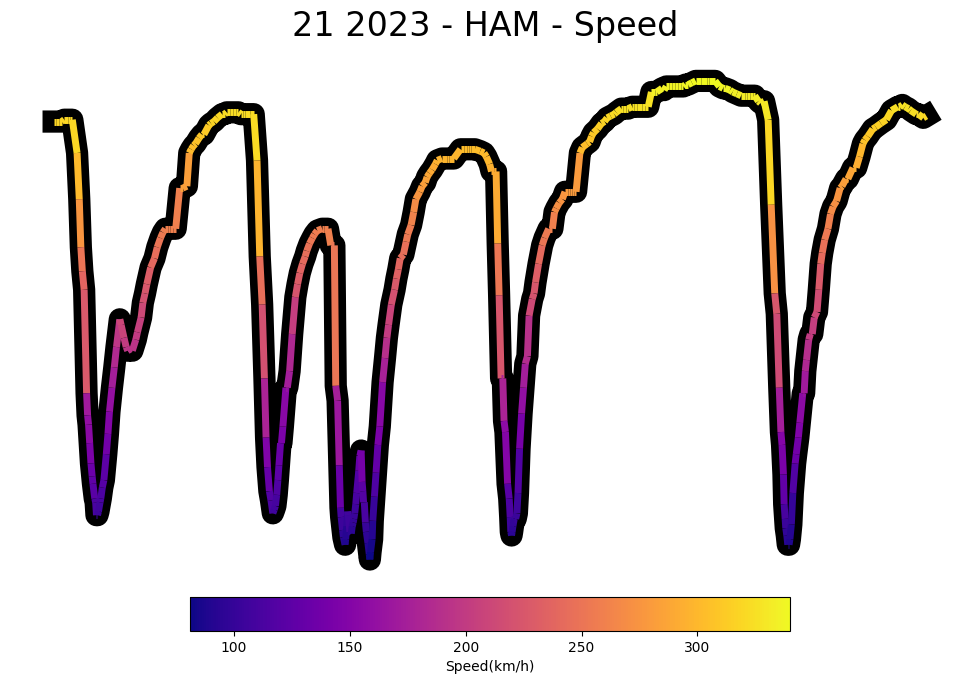

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6.75))
fig.suptitle(f'{weekend.name} {year} - {driver} - Speed ', size=24, y=0.97)
#plot backgroung track line
ax.plot(x,y, color='black', linestyle='-', linewidth=16, zorder=0)
#create line collection for colored track
y=tel['Speed']
x=tel['Distance']
speed=tel['Speed']
norm = plt.Normalize(y.min(), y.max())
lc = LineCollection(segments, cmap=colormap, norm=norm, linestyle='-', linewidth =5)
lc.set_array(y)
ax.add_collection(lc)
#color bar
cbaxes = fig.add_axes([0.25, 0.05, 0.5, 0.05])
normlenght = mp.colors.Normalize(vmin=speed.min(), vmax=speed.max())
mp.colorbar.ColorbarBase(cbaxes, cmap=colormap, norm=normlenght, orientation="horizontal", label="Speed(km/h)")
#adjust plot
ax.axis("off")
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.12)
plt.show()